# BPE Tokenizer — Interactive Demo

**Byte Pair Encoding (BPE)** is a subword tokenization algorithm used in modern NLP models (GPT, LLaMA, and others). It starts from individual characters and iteratively merges the most frequent adjacent pairs into new tokens, building a vocabulary that balances character-level granularity with word-level efficiency.

This notebook walks through a from-scratch BPE implementation trained on the Tiny Shakespeare corpus: corpus statistics, training dynamics, merge rules, tokenization examples, and sequence-length compression.

In [1]:
import os
import sys
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

_cwd = os.path.abspath(os.getcwd())
PROJECT_ROOT = (
    os.path.abspath(os.path.join(_cwd, ".."))
    if os.path.basename(_cwd) == "notebooks"
    else _cwd
)

os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from bpe.corpus import download_corpus, load_corpus
from bpe.trainer import train
from bpe.tokenizer import BPETokenizer

plt.style.use("seaborn-v0_8-whitegrid")
BLUE = "#4C72B0"
ORANGE = "#DD8452"

## 1. Corpus

We train on **Tiny Shakespeare** — a compact subset of Shakespeare's plays widely used in NLP tutorials (including Andrej Karpathy's char-rnn). Despite its small size (~1 MB), it contains rich character and word patterns that make BPE behavior easy to visualize.

In [2]:
download_corpus()
text = load_corpus()

total_chars = len(text)
total_words = len(text.split())
unique_chars = sorted(set(text))

print(f"Total characters: {total_chars:,}")
print(f"Total words: {total_words:,}")
print(f"Unique characters ({len(unique_chars)}): {unique_chars}")

Total characters: 1,115,394
Total words: 202,651
Unique characters (65): ['\n', ' ', '!', '$', '&', "'", ',', '-', '.', '3', ':', ';', '?', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']


## 2. Initial Vocabulary — Character Frequencies

BPE begins with a **character-level vocabulary**: every unique symbol in the corpus is a token. Spaces are handled at the word level (each word is split on whitespace, with a special `</w>` end-of-word marker appended during training). Understanding character frequencies reveals which pairs BPE will merge first.

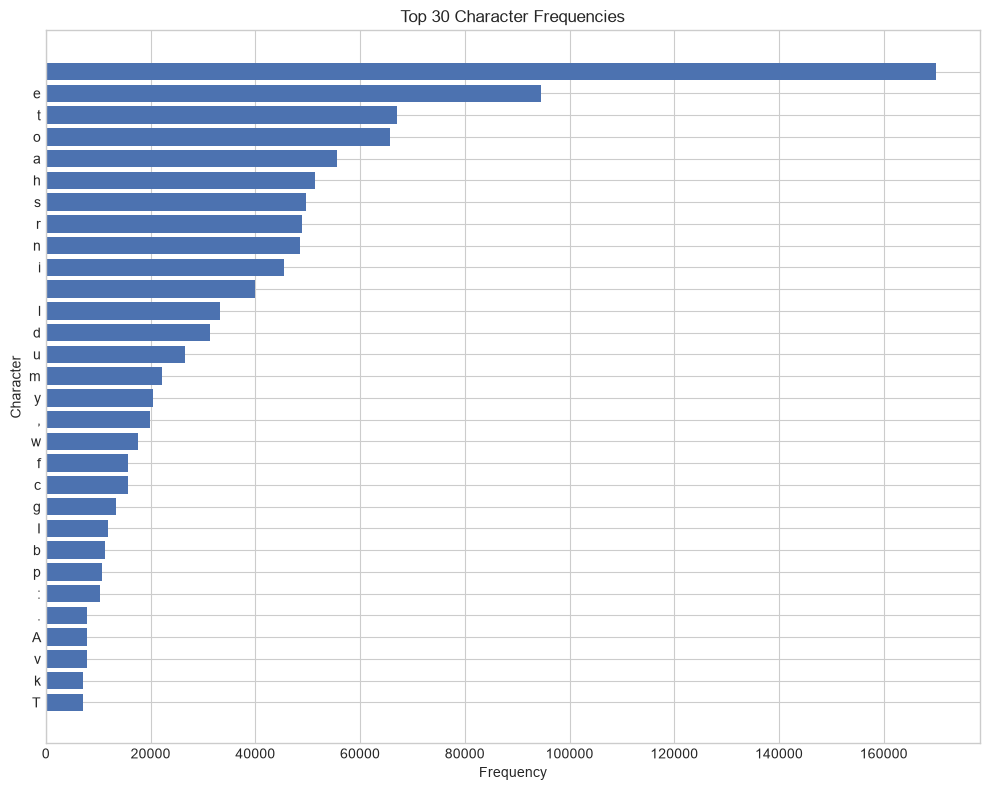

In [3]:
outputs_dir = "outputs"
os.makedirs(outputs_dir, exist_ok=True)

char_freq = Counter(text)
top_30 = char_freq.most_common(30)
chars, freqs = zip(*reversed(top_30))

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(chars, freqs, color=BLUE)
ax.set_xlabel("Frequency")
ax.set_ylabel("Character")
ax.set_title("Top 30 Character Frequencies")
plt.tight_layout()
fig.savefig(os.path.join(outputs_dir, "char_frequencies.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 3. BPE Training

The training loop repeats three steps:
1. Count all adjacent symbol pairs across the vocabulary.
2. Merge the **most frequent pair** into a new token.
3. Record the merge rule and repeat.

After 500 merges, the vocabulary contains both original characters and learned subword units.

In [4]:
result = train(text, num_merges=500)

print(f"Vocabulary size: {result['vocab_size']}")
print("\nFirst 10 merge rules:")
for symbol_a, symbol_b, merged in result["merges"][:10]:
    print(f"  ({symbol_a!r}, {symbol_b!r}) -> {merged!r}")

Training BPE:   0%|          | 0/500 [00:00<?, ?it/s]

Training BPE:   0%|          | 2/500 [00:00<01:09,  7.22it/s]

Training BPE:   1%|          | 3/500 [00:00<02:27,  3.36it/s]

Training BPE:   1%|          | 4/500 [00:00<02:06,  3.91it/s]

Training BPE:   1%|          | 5/500 [00:01<01:45,  4.68it/s]

...

Training BPE:  99%|█████████▊| 493/500 [00:50<00:00, 26.90it/s]

Training BPE:  99%|█████████▉| 496/500 [00:50<00:00, 26.76it/s]

Training BPE: 100%|█████████▉| 499/500 [00:50<00:00, 27.01it/s]

Training BPE: 100%|██████████| 500/500 [00:50<00:00,  9.91it/s]

Vocabulary size: 564

First 10 merge rules:
  ('e', '</w>') -> 'e</w>'
  ('t', 'h') -> 'th'
  (',', '</w>') -> ',</w>'
  ('t', '</w>') -> 't</w>'
  ('s', '</w>') -> 's</w>'
  ('d', '</w>') -> 'd</w>'
  ('o', 'u') -> 'ou'
  ('e', 'r') -> 'er'
  ('y', '</w>') -> 'y</w>'
  ('i', 'n') -> 'in'


## 4. Vocabulary Growth

Each merge adds exactly one new token to the vocabulary (while keeping all existing ones). The vocabulary grows roughly linearly with the number of merge steps — starting from the initial character set and expanding by one subword per iteration.

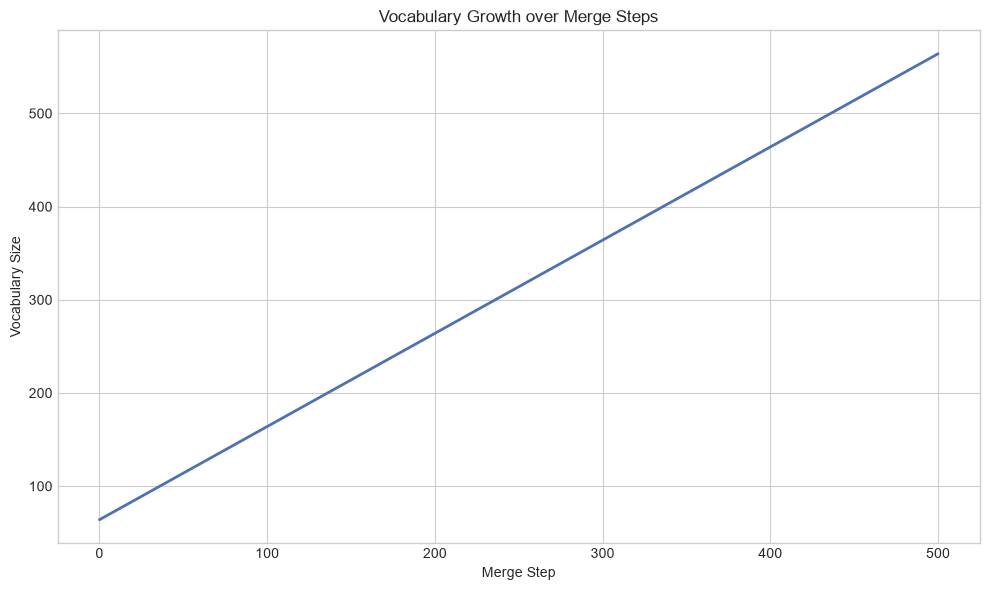

In [5]:
from bpe.trainer import get_pairs, get_vocab, merge_vocab

NUM_MERGES = 500
RECORD_EVERY = 10

vocab_counter = get_vocab(text)
token_set: set[str] = set()
for word_tuple in vocab_counter:
    token_set.update(word_tuple)

merge_steps = [0]
vocab_sizes = [len(token_set)]

for step in range(1, NUM_MERGES + 1):
    pairs = get_pairs(vocab_counter)
    if not pairs:
        break

    best_pair, _ = pairs.most_common(1)[0]
    symbol_a, symbol_b = best_pair
    merged = symbol_a + symbol_b

    token_set.add(merged)
    vocab_counter = merge_vocab(best_pair, vocab_counter)

    if step % RECORD_EVERY == 0 or step == NUM_MERGES:
        merge_steps.append(step)
        vocab_sizes.append(len(token_set))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(merge_steps, vocab_sizes, color=BLUE, linewidth=2)
ax.set_xlabel("Merge Step")
ax.set_ylabel("Vocabulary Size")
ax.set_title("Vocabulary Growth over Merge Steps")
plt.tight_layout()
fig.savefig(os.path.join(outputs_dir, "vocab_growth.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 5. Top Merge Rules

The **earliest merge rules** correspond to the most statistically dominant character pairs in the corpus — common letter combinations like `th`, `er`, and end-of-word markers. These rules have the highest impact on compression.

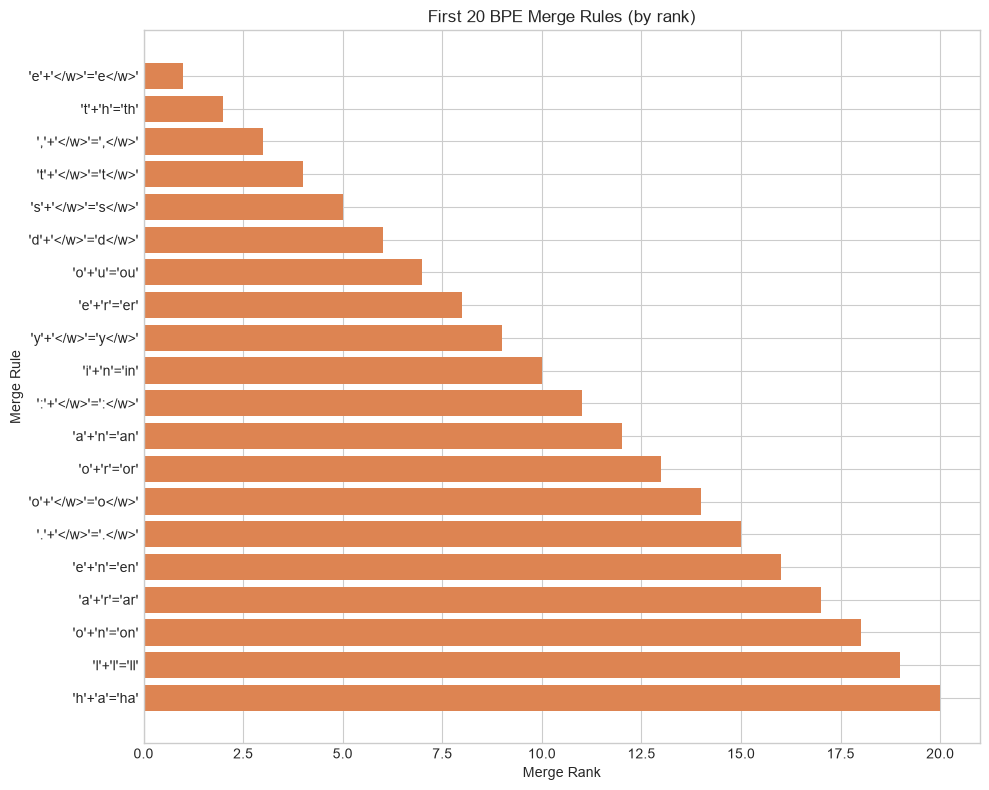

In [6]:
top_merges = result["merges"][:20]
labels = [f"{symbol_a!r}+{symbol_b!r}={merged!r}" for symbol_a, symbol_b, merged in top_merges]
ranks = list(range(1, len(top_merges) + 1))

fig, ax = plt.subplots(figsize=(10, 8))
y_pos = np.arange(len(labels))
ax.barh(y_pos, ranks, color=ORANGE)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("Merge Rank")
ax.set_ylabel("Merge Rule")
ax.set_title("First 20 BPE Merge Rules (by rank)")
plt.tight_layout()
fig.savefig(os.path.join(outputs_dir, "top_merges.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## 6. Tokenization in Action

Given a trained vocabulary and ordered merge rules, the `BPETokenizer` encodes text into integer IDs and decodes them back. Below we tokenize four real lines from *Coriolanus* (the opening scene of Tiny Shakespeare).

In [7]:
sentences = [
    "Before we proceed any further, hear me speak.",
    "Speak, speak.",
    "You are all resolved rather to die than to famish?",
    "Let us kill him, and we'll have corn at our own price.",
]

tokenizer = BPETokenizer(result["vocab"], result["merges"])

for sentence in sentences:
    token_ids = tokenizer.encode(sentence)
    decoded = tokenizer.decode(token_ids)

    preview = token_ids[:10]
    suffix = "..." if len(token_ids) > 10 else ""

    print(f"Original:  {sentence!r}")
    print(f"Tokens:    {len(token_ids)}")
    print(f"Token IDs: {preview}{suffix}")
    print(f"Decoded:   {decoded!r}")
    assert decoded.lower() == sentence.lower()
    print()

Original:  'Before we proceed any further, hear me speak.'
Tokens:    18
Token IDs: [37, 204, 244, 539, 412, 170, 212, 147, 557, 237]...
Decoded:   'Before we proceed any further, hear me speak.'

Original:  'Speak, speak.'
Tokens:    7
Token IDs: [112, 400, 209, 305, 460, 304, 16]
Decoded:   'Speak, speak.'

Original:  'You are all resolved rather to die than to famish?'
Tokens:    18
Token IDs: [137, 151, 145, 421, 369, 521, 212, 417, 493, 507]...
Decoded:   'You are all resolved rather to die than to famish?'

Original:  "Let us kill him, and we'll have corn at our own price."
Tokens:    21
Token IDs: [88, 234, 519, 304, 287, 326, 281, 11, 149, 538]...
Decoded:   "Let us kill him, and we'll have corn at our own price."



## 7. Sequence Length Compression

A key benefit of BPE is **shorter sequences**: common subwords are represented as single tokens instead of individual characters. This reduces memory and compute for downstream models while preserving reconstructability.

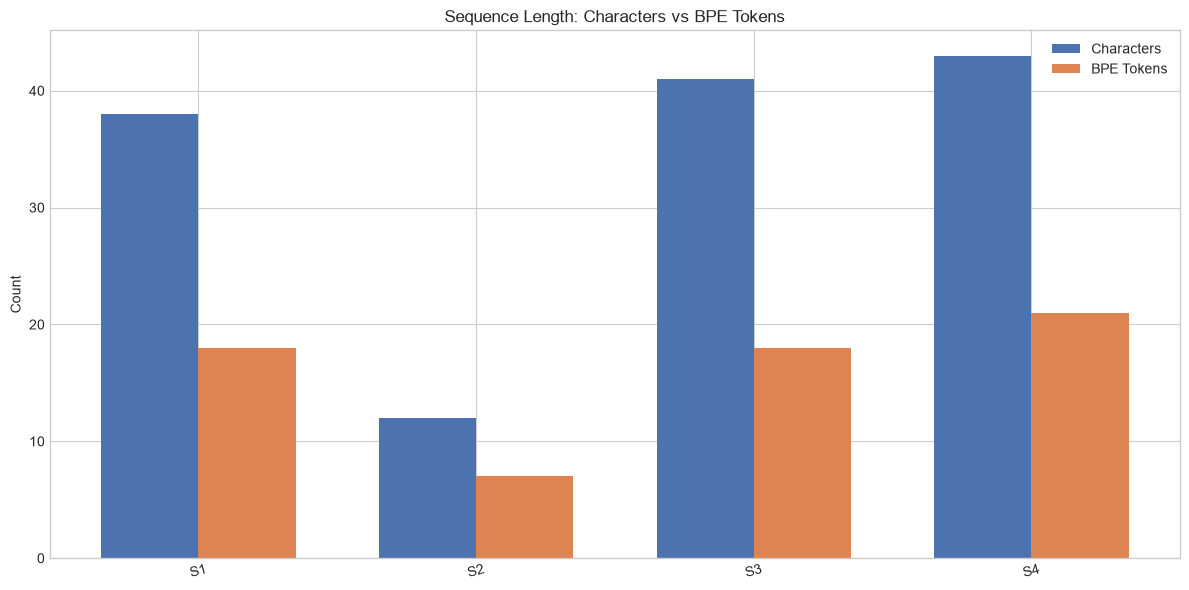

In [8]:
char_lengths = [len(sentence.replace(" ", "")) for sentence in sentences]
token_lengths = [len(tokenizer.encode(sentence)) for sentence in sentences]

x = np.arange(len(sentences))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width / 2, char_lengths, width, label="Characters", color=BLUE)
ax.bar(x + width / 2, token_lengths, width, label="BPE Tokens", color=ORANGE)
ax.set_xticks(x)
ax.set_xticklabels([f"S{i + 1}" for i in range(len(sentences))], rotation=15)
ax.set_ylabel("Count")
ax.set_title("Sequence Length: Characters vs BPE Tokens")
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(outputs_dir, "compression.png"), dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)

## Summary

This notebook demonstrated:

- **Corpus statistics** — Tiny Shakespeare contains ~1.1M characters with a compact set of unique symbols.
- **Character frequencies** — the starting point for BPE, where common letters dominate.
- **Vocabulary growth** — linear expansion from characters to 500+ subword tokens over merge steps.
- **Merge rules** — the earliest merges capture high-frequency pairs like `th`, `er`, and word endings.
- **Tokenization** — lossless encode/decode roundtrips on real Shakespeare sentences.
- **Compression** — BPE consistently produces shorter sequences than character-level representation.

The full implementation lives in the `bpe/` package: `corpus.py` (data loading), `trainer.py` (BPE algorithm), and `tokenizer.py` (encode/decode).